In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, GlobalAveragePooling2D, LSTM
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dropout
import numpy as np
import pandas as pd
import xgboost as xgb
import io
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
import os
import math
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc
import seaborn as sns
%matplotlib inline
#맥에서 한글 안깨지게


rc('font', family='AppleGothic') # 애플 폰트 사용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 안깨지게 설정

In [2]:
# 1-1. 사용자 설정 경로 및 변수
GANGNAM_DIRECTORY = '../../data/raw/'
IMAGE_DIRECTORY = '../../data/interim/satellites/gang_nam_rot_90'

TABULAR_DATA_PATH = '../../data/interim/gang_nam_sendimental_score_with_sale.csv'
INTEREST_RATE_PATH = GANGNAM_DIRECTORY+'한국은행_기준금리.csv'
POPLURATION_PATH = GANGNAM_DIRECTORY+'강남_주민등록세대수.csv'

IMAGE_EXTENSION = '.jpg' # 이미지 파일 확장자 (.png, .jpeg 등)
DATE_COLUMN = '계약일자'
TARGET_COLUMN = '면적당 단가(만원)' # 예측할 실제 타겟 컬럼명

# 1-2. 모델 파라미터
LOOKBACK = 10      # 과거 10개의 거래 데이터를 보고 다음 거래를 예측
BATCH_SIZE = 64
EPOCHS = 100

In [3]:
# 2-1. CSV 파일 로드 및 날짜 기준 정렬
#print("1. 데이터를 로드하고 정렬합니다...")
df = pd.read_csv(TABULAR_DATA_PATH)
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
df = df.sort_values(DATE_COLUMN).reset_index(drop=True)

In [4]:
df.head()

,전용면적(㎡),거래금액(만원),층,건축년도,면적당 단가(만원),아파트 나이,구,계약일자,계약년월,alpha,sentiment_score
0,84.96,115000,6,2011,7.210507,9,강남구,2020-07-11,202007,1.000000,0.014421
1,59.40,134000,4,1997,7.721301,23,강남구,2020-07-11,202007,0.233333,0.014421
2,84.83,139000,6,2013,7.401580,7,강남구,2020-07-11,202007,1.000000,0.014421
3,96.98,210000,12,1984,7.680358,36,강남구,2020-07-11,202007,0.000000,0.014421
4,111.96,91000,2,2004,6.700473,16,강남구,2020-07-11,202007,0.466667,0.014421


In [5]:
df['date'] = df['계약일자'].dt.strftime('%Y-%m')

# 한국은행기준금리

In [6]:
interest_rate = pd.read_csv(INTEREST_RATE_PATH)

In [7]:
interest_rate = interest_rate.iloc[:,13:]

In [8]:
interest_rate.head()

,2020/07,2020/08,2020/09,2020/10,2020/11,2020/12,2021/01,2021/02,2021/03,2021/04,...,2024/09,2024/10,2024/11,2024/12,2025/01,2025/02,2025/03,2025/04,2025/05,2025/06
0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,3.5,3.25,3.0,3.0,3.0,2.75,2.75,2.75,2.5,2.5


In [9]:
interest_rate = interest_rate.melt(var_name='date', value_name='rate')

In [10]:
# datetime 변환
interest_rate['date'] = pd.to_datetime(interest_rate['date'], format='%Y/%m')
interest_rate['date'] = interest_rate['date'].dt.strftime('%Y-%m')

In [11]:
interest_rate.head()

,date,rate
0,2020-07,0.5
1,2020-08,0.5
2,2020-09,0.5
3,2020-10,0.5
4,2020-11,0.5


# 시계열 강남 인구수

In [12]:
population = pd.read_csv(POPLURATION_PATH)

In [13]:
population.columns = ['date', 'pop']

In [14]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    60 non-null     float64
 1   pop     60 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [15]:
population['date'] = population['date'].astype(str)
population['date'] = pd.to_datetime(population['date'], format="%Y.%m")

In [16]:
population['date'] = population['date'].dt.strftime('%Y-%m')

In [17]:
population

,date,pop
0,2020-07,233673
1,2020-08,234024
2,2020-09,234021
3,2020-01,234588
4,2020-11,234785
5,2020-12,234872
6,2021-01,234688
7,2021-02,234776
8,2021-03,233363
9,2021-04,233203


# 모든 데이터 병합 및 전처리

In [18]:
df1 = pd.merge(population, interest_rate, on='date')

In [19]:
df = pd.merge(df, df1, on='date')

In [20]:
df.columns

Index(['전용면적(㎡)', '거래금액(만원)', '층', '건축년도', '면적당 단가(만원)', '아파트 나이', '구', '계약일자',
       '계약년월', 'alpha', 'sentiment_score', 'date', 'pop', 'rate'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8783 entries, 0 to 8782
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   전용면적(㎡)          8783 non-null   float64       
 1   거래금액(만원)         8783 non-null   int64         
 2   층                8783 non-null   int64         
 3   건축년도             8783 non-null   int64         
 4   면적당 단가(만원)       8783 non-null   float64       
 5   아파트 나이           8783 non-null   int64         
 6   구                8783 non-null   object        
 7   계약일자             8783 non-null   datetime64[ns]
 8   계약년월             8783 non-null   int64         
 9   alpha            8783 non-null   float64       
 10  sentiment_score  8783 non-null   float64       
 11  date             8783 non-null   object        
 12  pop              8783 non-null   int64         
 13  rate             8783 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(

In [22]:
drop_col = ['거래금액(만원)','구','계약년월','date']#,'alpha','sentiment_score']

In [23]:
df.drop(drop_col, axis=1,inplace=True)

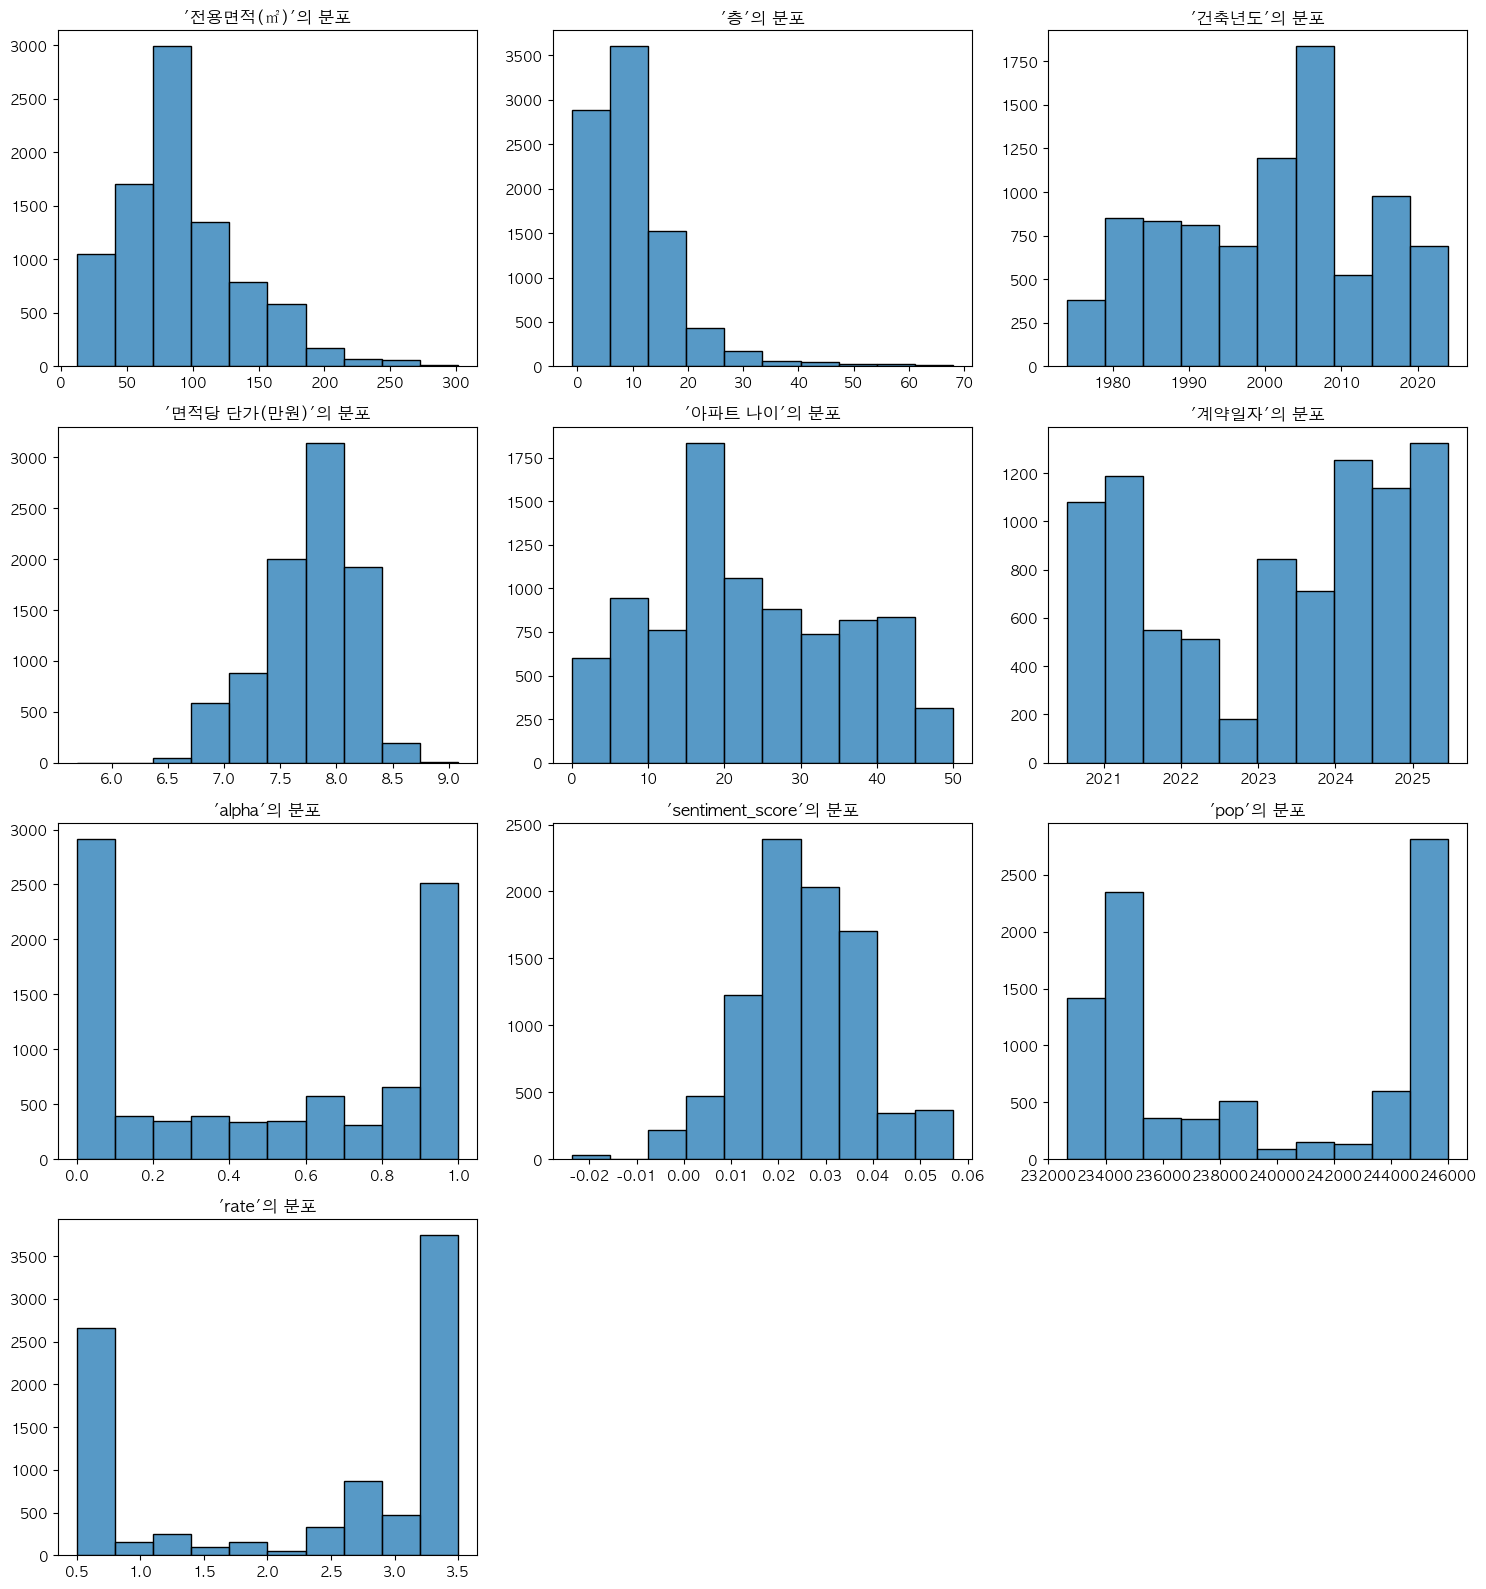

In [24]:
# 2. 각 피처(항목)별로 히스토그램 및 KDE 플롯 시각화
features = df.columns
num_features = len(features) # 여기서 num_features는 7이 됩니다.

# 피처 개수에 맞춰 격자의 행과 열 개수를 자동으로 계산
n_cols = 3 # 한 줄에 그릴 그래프 개수
# 필요한 행의 개수를 계산 (예: 7개 피처면 3줄 필요 -> (7/3) 올림 = 3)
n_rows = math.ceil(num_features / n_cols) 

# 전체 그림 크기를 조절 (한 그래프당 가로 5, 세로 4 정도로 가정)
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, feature in enumerate(features):
    # 계산된 행, 열 개수를 subplot에 적용
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.histplot(df[feature], bins=10) # 데이터 개수가 적으므로 bins를 2-3개로 줄여보세요.
    plt.title(f"'{feature}'의 분포", fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()


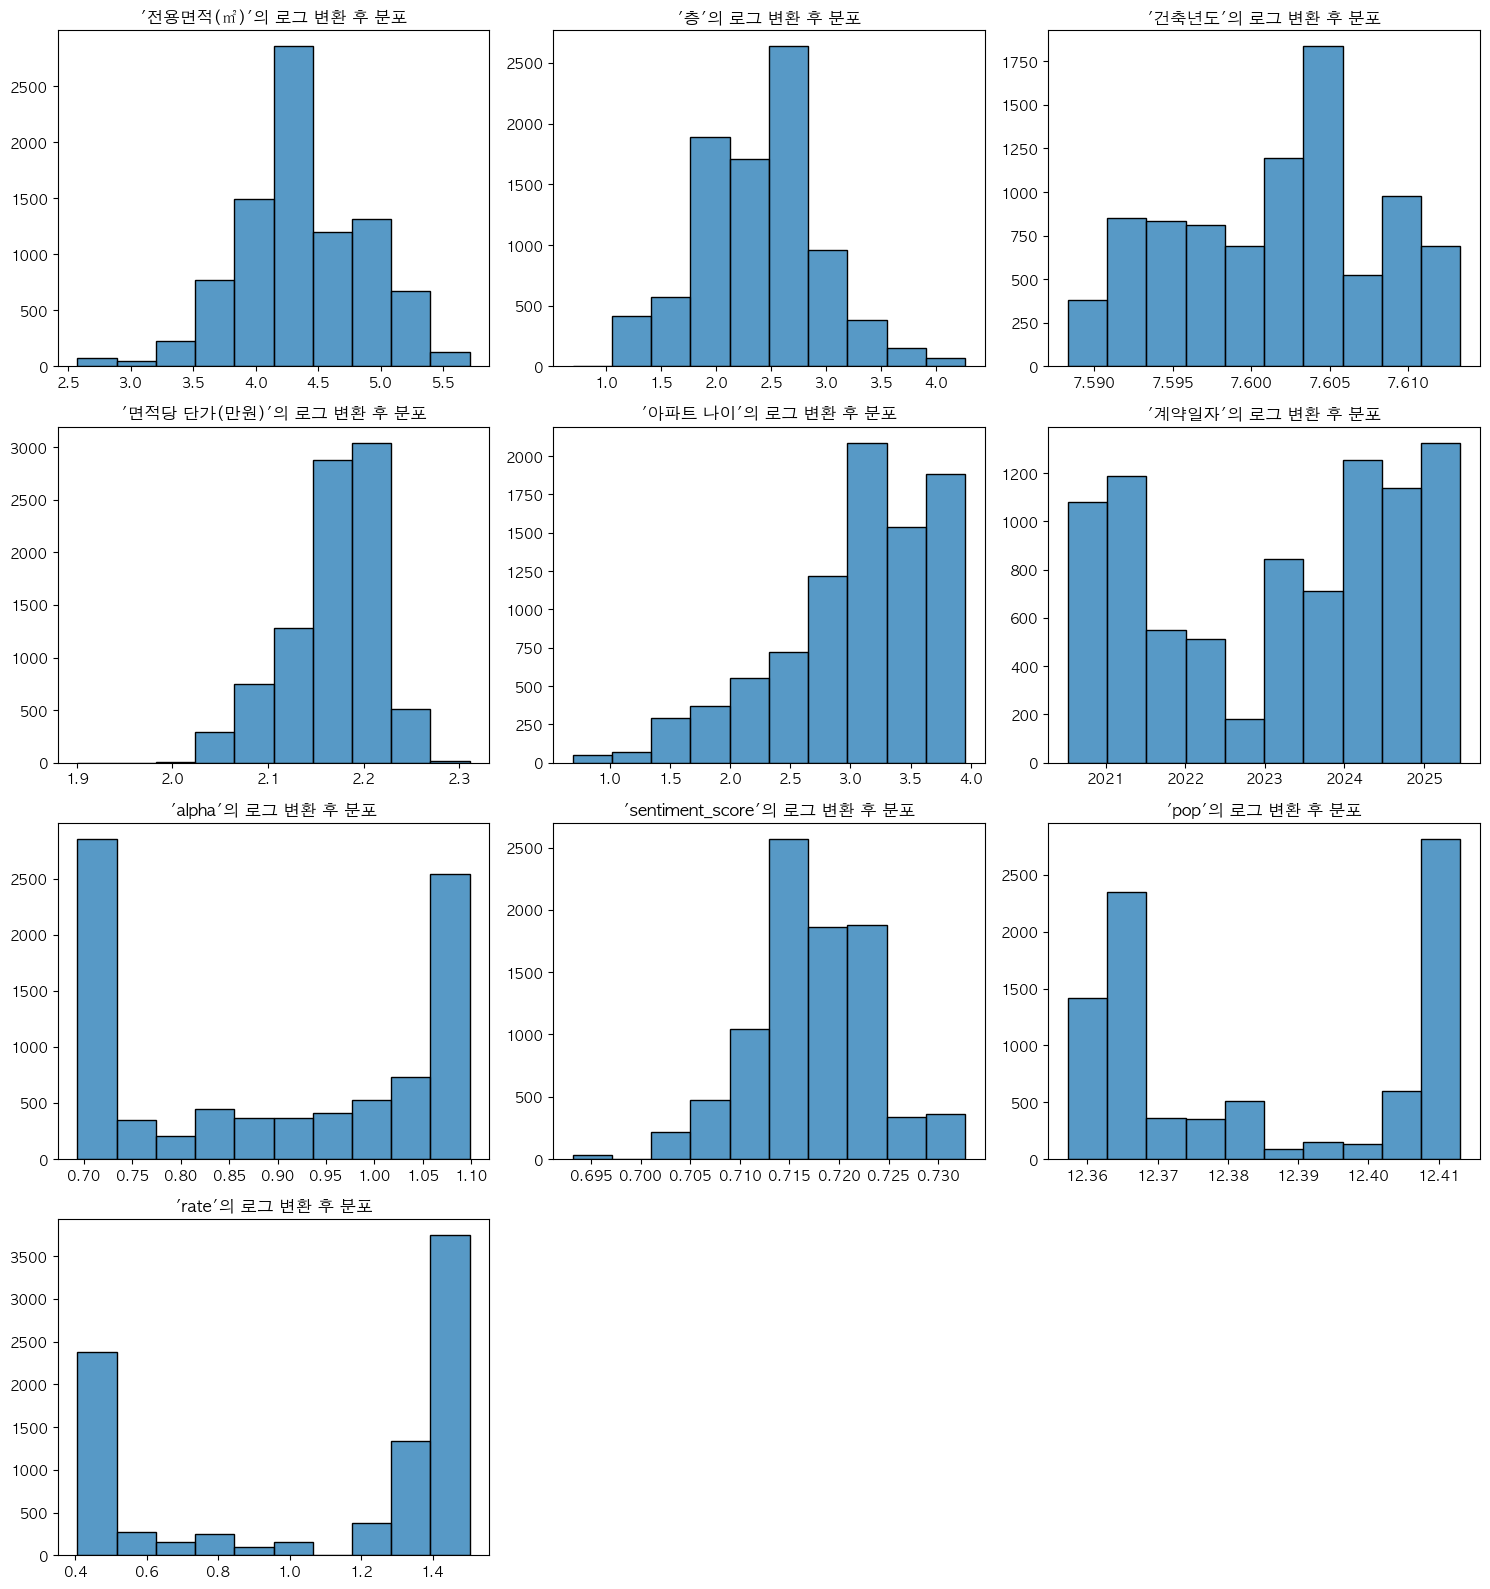

In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df_log_transformed = df.copy() # 원본 df를 보호하기 위해 복사

for col in numeric_cols:
    # 컬럼의 최솟값을 확인하여 0보다 작거나 같은 경우 처리
    min_val = df[col].min()
    if min_val <= 0:
        # 모든 값을 양수로 만들고 로그 변환 (가장 안전한 방법)
        # 최솟값이 0이면 1을 더하고, 음수이면 그 절댓값에 1을 더해서 모든 값을 1 이상으로 만듦
        df_log_transformed[col] = np.log1p(df[col] - min_val + 1)
    else:
        # 모든 값이 양수이면 바로 log1p 적용
        df_log_transformed[col] = np.log1p(df[col])

# ---------------------------------------------------------------------
features_to_plot = df_log_transformed.columns
num_features_to_plot = len(features_to_plot)

n_cols = 3
n_rows = math.ceil(num_features_to_plot / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, feature in enumerate(features_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    # bins는 데이터 개수에 따라 조절하세요. 현재 4개이므로 bins는 2-3개가 적절합니다.
    sns.histplot(df_log_transformed[feature], bins=10) 
    plt.title(f"'{feature}'의 로그 변환 후 분포", fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [57]:
# 2-2. 이미지 전체 경로 생성
df['image_filename'] = [f'apt_image_{i}{IMAGE_EXTENSION}' for i in df.index]
df['image_path'] = df['image_filename'].apply(lambda filename: os.path.join(IMAGE_DIRECTORY, filename))

# 2-3. 특징(X)과 타겟(y) 분리
X_tabular = df.drop(columns=[TARGET_COLUMN, DATE_COLUMN, 'image_path', 'image_filename'])
y_target = df[TARGET_COLUMN]

# 2-4. 숫자형 특징 스케일링
#print("2. 데이터를 전처리합니다...")
numeric_features = X_tabular.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
#scaler = RobustScaler()
#scaler = MinMaxScaler()
X_tabular[numeric_features] = scaler.fit_transform(X_tabular[numeric_features])
print("=========================")
print("최종 전처리 완료된 데이터 입니다.")
print("=========================\n")
df.info()

최종 전처리 완료된 데이터 입니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8783 entries, 0 to 8782
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   전용면적(㎡)          8783 non-null   float64       
 1   층                8783 non-null   int64         
 2   건축년도             8783 non-null   int64         
 3   면적당 단가(만원)       8783 non-null   float64       
 4   아파트 나이           8783 non-null   int64         
 5   계약일자             8783 non-null   datetime64[ns]
 6   alpha            8783 non-null   float64       
 7   sentiment_score  8783 non-null   float64       
 8   pop              8783 non-null   int64         
 9   rate             8783 non-null   float64       
 10  image_filename   8783 non-null   object        
 11  image_path       8783 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(4), object(2)
memory usage: 823.5+ KB


In [58]:
X_tabular.describe()

,전용면적(㎡),층,건축년도,아파트 나이,alpha,sentiment_score,pop,rate
count,8.783000e+03,8.783000e+03,8.783000e+03,8.783000e+03,8.783000e+03,8.783000e+03,8.783000e+03,8.783000e+03
mean,-2.499803e-16,-6.896706e-17,-2.658367e-15,-9.060775e-17,8.089978e-17,-1.294396e-16,1.812155e-16,-3.947909e-16
std,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00
min,-1.801994e+00,-1.339814e+00,-2.100247e+00,-1.818111e+00,-1.179238e+00,-3.817606e+00,-1.271903e+00,-1.378724e+00
25%,-7.294735e-01,-7.217360e-01,-6.522980e-01,-6.930331e-01,-1.179238e+00,-5.957644e-01,-9.015494e-01,-1.378724e+00
50%,-1.715834e-01,-2.272737e-01,1.521183e-01,-2.108571e-01,2.519842e-02,-2.129708e-02,-2.918655e-01,3.539309e-01
75%,5.042750e-01,3.908043e-01,6.347680e-01,7.534950e-01,1.229635e+00,6.302330e-01,1.157431e+00,9.314824e-01
max,4.684011e+00,7.189662e+00,1.921834e+00,2.200023e+00,1.229635e+00,2.504633e+00,1.345252e+00,9.314824e-01


# 다중 모달 특징 추출

In [59]:
# --- 3. 다중 모달 특징 추출 ---

# 3-1. 특징 추출기 모델 정의 (수정 없음, Input 레이어의 name이 중요해짐)
print("3. 특징 추출기 모델을 정의합니다...")
def create_feature_extractor_model(num_tabular_features, image_shape=(224, 224, 3)):
    # --- 입력층 정의 ---
    # 1. 인구통계, 주택 관련, KDE 특징을 포함하는 정형 데이터 입력
    tabular_input = Input(shape=(num_tabular_features,), name='tabular_input')
    # 2. 이미지 데이터 입력
    image_input = Input(shape=image_shape, name='image_input')
    
    
    # --- 특징별 처리 스트림 ---
    
    # 이미지 특징 처리 부분 (3개의 은닉층) 
    base_cnn = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)
    base_cnn.trainable = False
    x_image = GlobalAveragePooling2D()(base_cnn.output)
    x_image = Dense(128, activation='relu')(x_image)
    x_image = Dense(64, activation='relu')(x_image)
    image_features = Dense(32, activation='relu')(x_image)

    # 정형 데이터(인구통계, 주택, KDE) 처리 부분 (1개의 은닉층) 
    tabular_features = Dense(64, activation='relu')(tabular_input)

    
    # --- 특징 결합 및 최종 예측 ---
    
    # 두 부분의 출력을 결합 
    combined = Concatenate()([image_features, tabular_features])
    
    # 결합된 특징을 256개 뉴런을 가진 은닉층으로 처리 
    x = Dense(256, activation='relu')(combined)
    
    # 최종 가격을 예측하는 출력 뉴런 
    # 벡터형태로 LSTM에 넘겨야해서 주석처리 ㄱㄱ
    # prediction = Dense(1, activation='linear', name='price_output')(x)
    
    # --- 모델 생성 ---
    model = Model(inputs=[tabular_input, image_input], outputs=x, name='apartment_predictor')
    
    return model

# 3-2. 특징 추출을 위한 데이터 제너레이터 (수정됨)
def prediction_generator(tabular_data, image_paths, batch_size, image_shape=(224, 224, 3)):
    num_samples = len(tabular_data)
    for offset in range(0, num_samples, batch_size):
        batch_tabular = tabular_data.iloc[offset:offset+batch_size].values
        batch_paths = image_paths.iloc[offset:offset+batch_size]
        
        batch_images = []
        for path in batch_paths:
            try:
                img = load_img(path, target_size=image_shape[:2])
                img_array = img_to_array(img) / 255.0
                batch_images.append(img_array)
            except FileNotFoundError:
                batch_images.append(np.zeros(image_shape))
        
        # 모델의 Input 레이어 이름에 맞춰 딕셔너리 형태로 반환
        yield {
            'tabular_input': np.array(batch_tabular),
            'image_input': np.array(batch_images)
        }

# 3-3. 전체 데이터에 대한 특징 추출 실행 
print("4. 전체 데이터에 대한 특징을 추출합니다...")
feature_extractor = create_feature_extractor_model(num_tabular_features=X_tabular.shape[1])

# 출력 형식을 딕셔너리 구조로 명시
output_signature = {
    'tabular_input': tf.TensorSpec(shape=(None, X_tabular.shape[1]), dtype=tf.float32),
    'image_input': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)
}

# from_generator를 사용하여 데이터셋 생성
pred_dataset = tf.data.Dataset.from_generator(
    lambda: prediction_generator(X_tabular, df['image_path'], BATCH_SIZE),
    output_signature=output_signature
)

# predict 함수에 tf.data.Dataset을 직접 전달
all_features = feature_extractor.predict(pred_dataset, verbose=1)

print("\n🎉 특징 추출이 성공적으로 완료되었습니다!")
print("추출된 특징의 모양:", all_features.shape)

3. 특징 추출기 모델을 정의합니다...
4. 전체 데이터에 대한 특징을 추출합니다...


2025-09-13 16:26:01.108880: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2025-09-13 16:26:01.123425: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


138/138 [==============================] - 174s 1s/step

🎉 특징 추출이 성공적으로 완료되었습니다!
추출된 특징의 모양: (8783, 256)


# 4.시퀸스 데이터 생성

In [60]:
# --- 4. 시퀀스 데이터 생성 ---

print("\n5. 시계열 데이터를 생성합니다...")
def create_sequences(X_data, y_data, lookback):
    X_sequences, y_sequences = [], []
    # 데이터 길이에서 lookback 길이를 뺀 만큼 반복
    for i in range(len(X_data) - lookback):
        # i부터 i+lookback까지의 데이터를 하나의 시퀀스로
        X_sequences.append(X_data[i:(i + lookback)])
        # 시퀀스 바로 다음의 데이터를 정답으로
        y_sequences.append(y_data[i + lookback])
    return np.array(X_sequences), np.array(y_sequences)

# 이전 단계에서 추출한 all_features와 원본 정답(y_target)을 사용
X_seq, y_seq = create_sequences(all_features, y_target.values, lookback=LOOKBACK)

print(f"생성된 시퀀스 데이터 모양 (X): {X_seq.shape}") # (샘플 수, 10, 96)
print(f"생성된 시퀀스 데이터 모양 (y): {y_seq.shape}") # (샘플 수,)


# 4-1. 훈련/테스트 데이터 분리 (시계열 데이터는 순서를 섞지 않음)
split_index = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_index], X_seq[split_index:]
y_train_seq, y_test_seq = y_seq[:split_index], y_seq[split_index:]



5. 시계열 데이터를 생성합니다...
생성된 시퀀스 데이터 모양 (X): (8773, 10, 256)
생성된 시퀀스 데이터 모양 (y): (8773,)


# 예측

In [61]:
def create_lstm_model(input_shape):
    input_layer = Input(shape=input_shape)
    x = LSTM(128, activation='relu', return_sequences=True)(input_layer)
    x = Dropout(0.2)(x)
    x = LSTM(64, activation='relu', return_sequences=True)(x)  
    prediction = Dense(1, activation='linear')(x)

    model = Model(inputs=input_layer, outputs=prediction, name='lstm_forecaster')
    return model

In [62]:
def create_future_sequences(all_features, original_df, lookback=10, horizon_days=30):
    """
    특정 기간(horizon_days) 후의 가격을 예측하기 위한 시계열 데이터를 생성합니다.
    
    :param all_features: (샘플 수, 특징 수) 모양의 전체 특징 데이터
    :param original_df: 날짜와 타겟 컬럼이 포함된 원본 데이터프레임
    :param lookback: 과거를 돌아볼 기간 (시퀀스 길이)
    :param horizon_days: 예측할 미래 기간 (일 단위)
    :return: X_sequences (입력 시퀀스), y_sequences (미래 시점의 정답)
    """
    X_sequences, y_sequences = [], []
    
    # 날짜와 타겟 값을 쉽게 조회할 수 있도록 Series로 변환
    dates = original_df['계약일자']
    targets = original_df[TARGET_COLUMN].values
    
    for i in range(len(all_features) - lookback):
        # 입력 시퀀스의 마지막 날짜
        end_of_input_sequence_date = dates[i + lookback - 1]
        
        # 예측 목표 날짜 설정
        target_date = end_of_input_sequence_date + pd.Timedelta(days=horizon_days)
        
        # 목표 날짜 이후의 데이터만 필터링
        future_data_indices = np.where(dates >= target_date)[0]
        
        # 목표 날짜 이후에 거래가 있다면
        if len(future_data_indices) > 0:
            # 가장 가까운 미래 거래의 인덱스를 찾음
            future_target_index = future_data_indices[0]
            
            # 해당 인덱스가 전체 특징 데이터 길이를 벗어나지 않는지 확인
            if future_target_index < len(all_features):
                # 입력 시퀀스 생성
                X_sequences.append(all_features[i:(i + lookback)])
                # 미래 시점의 가격을 정답으로 지정
                y_sequences.append(targets[future_target_index])
                
    return np.array(X_sequences), np.array(y_sequences)

In [63]:
# --- 4. 시퀀스 데이터 생성 (미래 예측용) ---

print("\n5. 미래 예측을 위한 시계열 데이터를 생성합니다...")

# 1개월 (약 30일) 후 가격 예측용 데이터셋 생성
print("1개월 후 예측 데이터셋 생성 중...")
X_seq_1m, y_seq_1m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=30)

# 3개월 (약 90일) 후 가격 예측용 데이터 생성함요
print("3개월 후 예측 데이터셋 생성 중...")
X_seq_3m, y_seq_3m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=60)

# 6개월 (약 180일) 후 가격 예측용 데이터셋 생성
print("6개월 후 예측 데이터셋 생성 중...")
X_seq_6m, y_seq_6m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=180)

print("\n======================================\n")
print(f"1개월 후 예측용 데이터 샘플 수: {len(X_seq_1m)}")
print(f"3개월 후 예측용 데이터 샘플 수: {len(X_seq_3m)}")
print(f"6개월 후 예측용 데이터 샘플 수: {len(X_seq_6m)}")


5. 미래 예측을 위한 시계열 데이터를 생성합니다...
1개월 후 예측 데이터셋 생성 중...
3개월 후 예측 데이터셋 생성 중...
6개월 후 예측 데이터셋 생성 중...


1개월 후 예측용 데이터 샘플 수: 8635
3개월 후 예측용 데이터 샘플 수: 8477
6개월 후 예측용 데이터 샘플 수: 7453


In [64]:
# --- 5-1 1개월 후 예측 모델 학습 ---

# 1, 3, 6개월 모델의 옵티마이저는 여기서 설정
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

# 'val_loss'(검증 손실)를 모니터링하면서, 5번의 에포크 동안 성능 개선이 없으면 학습을 중단합니다.
# restore_best_weights=True 옵션은 가장 성능이 좋았던 시점의 가중치로 모델을 되돌려줍니다.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# 데이터 분리
split_1m = int(len(X_seq_1m) * 0.8)
X_train_1m, X_test_1m = X_seq_1m[:split_1m], X_seq_1m[split_1m:]
y_train_1m, y_test_1m = y_seq_1m[:split_1m], y_seq_1m[split_1m:]

In [65]:
# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_1m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)
lstm_model_1m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 1개월 후 예측 모델 학습 시작 ---")
history_1m = lstm_model_1m.fit(
    X_train_1m, y_train_1m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1m, y_test_1m),
    callbacks=[early_stopping],
    verbose=1
)

# --- 5-2 3개월 후 예측 모델 학습 ---

# 데이터 분리
split_3m = int(len(X_seq_3m) * 0.8)
X_train_3m, X_test_3m = X_seq_3m[:split_3m], X_seq_3m[split_3m:]
y_train_3m, y_test_3m = y_seq_3m[:split_3m], y_seq_3m[split_3m:]

# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_3m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_3m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 3개월 후 예측 모델 학습 시작 ---")
history_3m = lstm_model_3m.fit(
    X_train_3m, y_train_3m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_3m, y_test_3m),
    callbacks=[early_stopping],
    verbose=1
)


# --- 5-3 6개월 후 예측 모델 학습 ---

# 데이터 분리
split_6m = int(len(X_seq_6m) * 0.8)
X_train_6m, X_test_6m = X_seq_6m[:split_6m], X_seq_6m[split_6m:]
y_train_6m, y_test_6m = y_seq_6m[:split_6m], y_seq_6m[split_6m:]

# 모델 생성 및 컴파일
lstm_model_6m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))

#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_6m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 6개월 후 예측 모델 학습 시작 ---")
history_1m = lstm_model_1m.fit(
    X_train_1m, y_train_1m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1m, y_test_1m),
    callbacks=[early_stopping],
    verbose=1
)


--- 1개월 후 예측 모델 학습 시작 ---
Epoch 1/100
108/108 [==============================] - 2s 11ms/step - loss: 58.9920 - mae: 7.6716 - val_loss: 62.1328 - val_mae: 7.8717
Epoch 2/100
108/108 [==============================] - 1s 10ms/step - loss: 57.5485 - mae: 7.5764 - val_loss: 59.9926 - val_mae: 7.7335
Epoch 3/100
108/108 [==============================] - 1s 11ms/step - loss: 54.0714 - mae: 7.3378 - val_loss: 53.6507 - val_mae: 7.2966
Epoch 4/100
108/108 [==============================] - 1s 11ms/step - loss: 41.8364 - mae: 6.2376 - val_loss: 36.3048 - val_mae: 5.5491
Epoch 5/100
108/108 [==============================] - 1s 12ms/step - loss: 33.6950 - mae: 5.3120 - val_loss: 33.9892 - val_mae: 5.3074
Epoch 6/100
108/108 [==============================] - 1s 11ms/step - loss: 31.0718 - mae: 5.0399 - val_loss: 31.4922 - val_mae: 5.0306
Epoch 7/100
108/108 [==============================] - 1s 12ms/step - loss: 28.0625 - mae: 4.6986 - val_loss: 27.8840 - val_mae: 4.5881
Epoch 8/100
108/108 [


--- 3개월 후 예측 모델 학습 시작 ---
Epoch 1/100
106/106 [==============================] - 2s 11ms/step - loss: 59.5124 - mae: 7.7045 - val_loss: 63.3232 - val_mae: 7.9463
Epoch 2/100
106/106 [==============================] - 1s 11ms/step - loss: 58.0204 - mae: 7.6068 - val_loss: 61.4679 - val_mae: 7.8281
Epoch 3/100
106/106 [==============================] - 1s 11ms/step - loss: 55.4513 - mae: 7.4336 - val_loss: 57.7112 - val_mae: 7.5801
Epoch 4/100
106/106 [==============================] - 1s 12ms/step - loss: 47.8329 - mae: 6.8478 - val_loss: 41.7992 - val_mae: 6.2186
Epoch 5/100
106/106 [==============================] - 1s 12ms/step - loss: 34.6087 - mae: 5.4254 - val_loss: 34.9733 - val_mae: 5.4009
Epoch 6/100
106/106 [==============================] - 1s 11ms/step - loss: 31.4206 - mae: 5.0780 - val_loss: 32.4439 - val_mae: 5.1247
Epoch 7/100
106/106 [==============================] - 1s 11ms/step - loss: 28.6935 - mae: 4.7773 - val_loss: 29.5240 - val_mae: 4.7850
Epoch 8/100
106/106 [


--- 6개월 후 예측 모델 학습 시작 ---
Epoch 1/100
108/108 [==============================] - 1s 11ms/step - loss: 0.2706 - mae: 0.3792 - val_loss: 0.4127 - val_mae: 0.5243
Epoch 2/100
108/108 [==============================] - 1s 11ms/step - loss: 0.2673 - mae: 0.3783 - val_loss: 0.4295 - val_mae: 0.5388
Epoch 3/100
108/108 [==============================] - 1s 12ms/step - loss: 0.2647 - mae: 0.3771 - val_loss: 0.4418 - val_mae: 0.5501
Epoch 4/100
108/108 [==============================] - 1s 11ms/step - loss: 0.2590 - mae: 0.3743 - val_loss: 0.4098 - val_mae: 0.5263
Epoch 5/100
108/108 [==============================] - 1s 11ms/step - loss: 0.2568 - mae: 0.3726 - val_loss: 0.4332 - val_mae: 0.5461
Epoch 6/100
108/108 [==============================] - 1s 12ms/step - loss: 0.2534 - mae: 0.3715 - val_loss: 0.4047 - val_mae: 0.5254
Epoch 7/100
108/108 [==============================] - 1s 12ms/step - loss: 0.2494 - mae: 0.3698 - val_loss: 0.4345 - val_mae: 0.5499
Epoch 8/100
108/108 [==============

In [66]:
import matplotlib.pyplot as plt
import pandas as pd # pd.Series를 위해 import
import numpy as np # np.expm1을 위해 import
from sklearn.metrics import mean_absolute_error

# --- 분석 및 시각화 함수 수정 ---
def analyze_and_visualize_model(model, X_test_seq, y_test_seq, model_name):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 예측 수행 (로그 스케일)
    y_pred_log = model.predict(X_test_seq)

    # ❗️ [수정] y_pred_log의 차원 확인 및 조정
    if y_pred_log.ndim >= 2:
        y_pred_log = y_pred_log.flatten()

    # 2. 역변환 (로그 -> 원본 단위)
    y_pred_original = np.expm1(y_pred_log)

    # ❗️ [수정] y_test_seq도 동일하게 차원 조정 및 역변환
    y_test_original = np.expm1(y_test_seq)
    
    if y_test_original.ndim >= 2:
        y_test_original = y_test_original.flatten()
        
    # ❗️ [수정] 두 배열의 길이를 동일하게 맞춰줍니다.
    #    예측값의 길이를 기준으로 실제값의 길이를 자릅니다.
    min_len = min(len(y_test_original), len(y_pred_original))
    y_test_np = y_test_original[:min_len]
    y_pred_original = y_pred_original[:min_len]


    # 3. 원본 단위(만원)로 MAE 계산
    real_world_mae = mean_absolute_error(y_test_np, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(min(5, len(y_test_np))):
        print(f"실제 단가: {y_test_np[i]:.2f} (만원)  |  예측 단가: {y_pred_original[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    print(f"Real World MAE: {real_world_mae:.2f} (만원)")

    # 5. 시각화
    plt.figure(figsize=(10, 10))
    plt.scatter(y_test_np, y_pred_original, alpha=0.5, label='예측 결과')
    
    min_val = min(y_test_np.min(), y_pred_original.min())
    max_val = max(y_test_np.max(), y_pred_original.max())
    
    plt.plot([min_val, max_val], [min_val, max_val], 
             '--r', linewidth=2, label='완벽한 예측선 (y=x)')
    
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name})", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


--- 1개월 후 예측 모델 성능 분석 시작 ---
54/54 [==============================] - 0s 2ms/step
--- 1개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1940.86 (만원)  |  예측 단가: 2868.61 (만원)
실제 단가: 1940.86 (만원)  |  예측 단가: 2140.98 (만원)
실제 단가: 1940.86 (만원)  |  예측 단가: 2100.93 (만원)
실제 단가: 1940.86 (만원)  |  예측 단가: 2025.30 (만원)
실제 단가: 1940.86 (만원)  |  예측 단가: 2080.01 (만원)

--- 1개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1236.91 (만원)


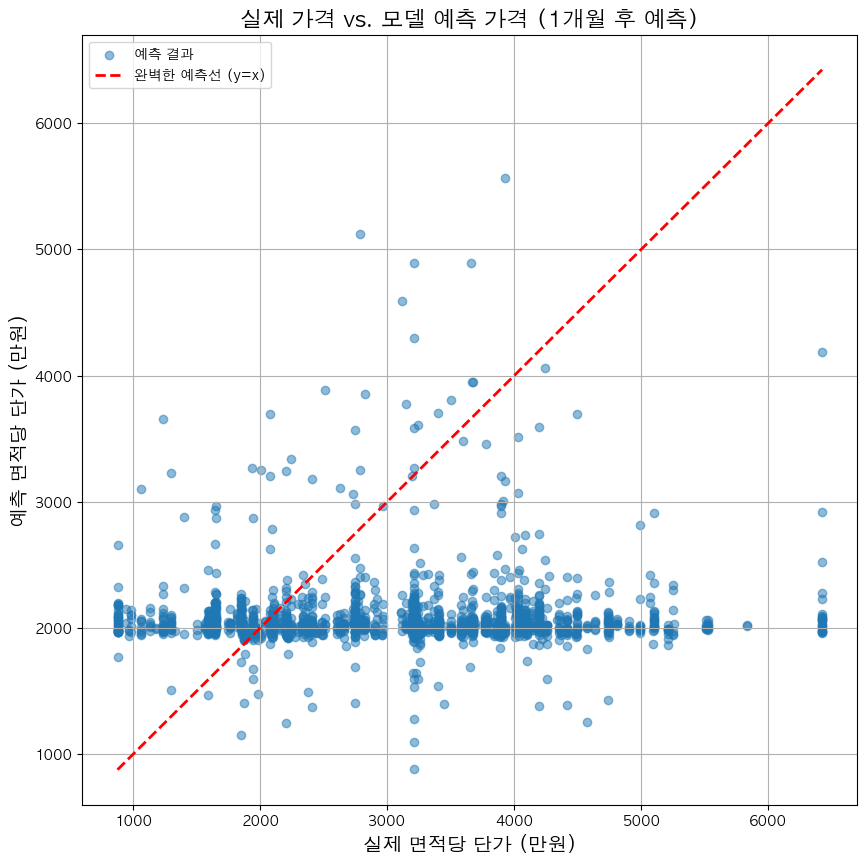


--- 3개월 후 예측 모델 성능 분석 시작 ---
53/53 [==============================] - 0s 2ms/step
--- 3개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 3214.32 (만원)  |  예측 단가: 3582.66 (만원)
실제 단가: 3214.32 (만원)  |  예측 단가: 2139.77 (만원)
실제 단가: 3214.32 (만원)  |  예측 단가: 2041.69 (만원)
실제 단가: 3214.32 (만원)  |  예측 단가: 1959.78 (만원)
실제 단가: 3214.32 (만원)  |  예측 단가: 2009.39 (만원)

--- 3개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1568.49 (만원)


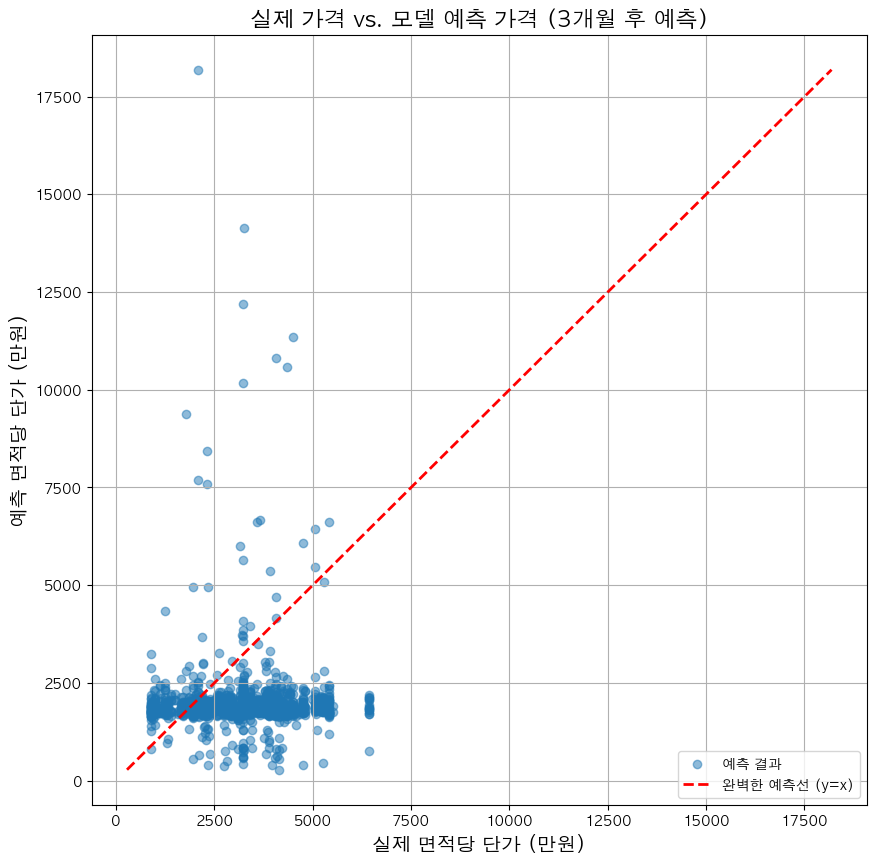


--- 6개월 후 예측 모델 성능 분석 시작 ---
47/47 [==============================] - 0s 2ms/step
--- 6개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 3884.10 (만원)  |  예측 단가: -0.00 (만원)
실제 단가: 3884.10 (만원)  |  예측 단가: -0.01 (만원)
실제 단가: 2892.31 (만원)  |  예측 단가: -0.01 (만원)
실제 단가: 2892.31 (만원)  |  예측 단가: -0.02 (만원)
실제 단가: 2892.31 (만원)  |  예측 단가: -0.03 (만원)

--- 6개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 3182.12 (만원)


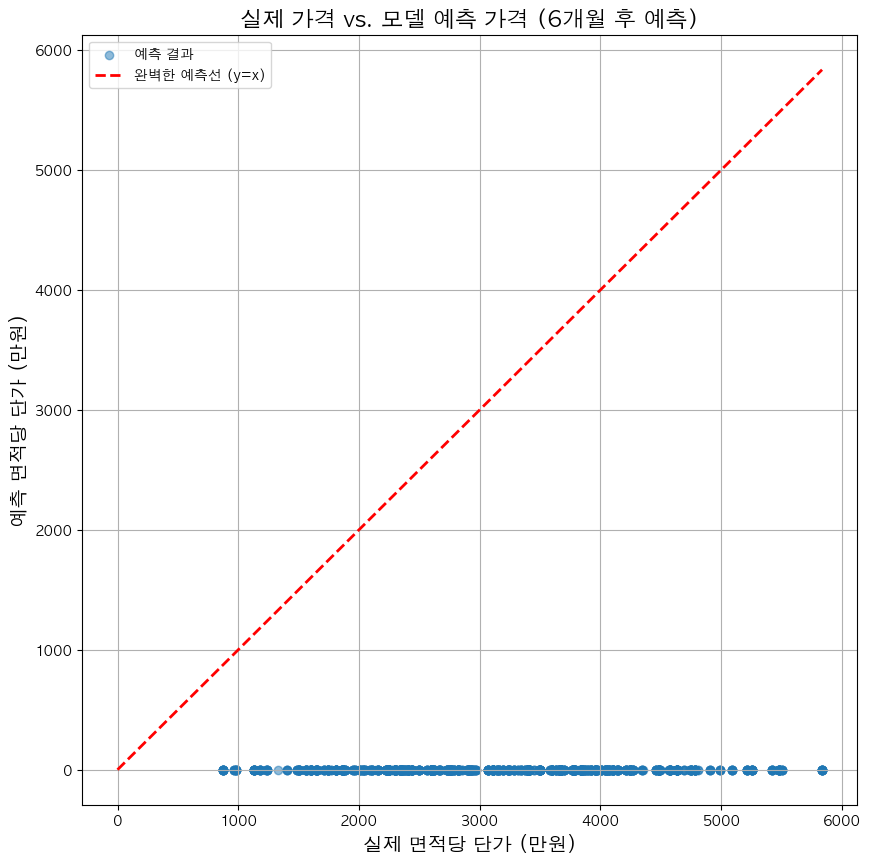

In [67]:

# --- 함수 실행 (기존 코드와 동일) ---
# 1개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_1m, X_test_1m, y_test_1m, "1개월 후 예측")

# 3개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_3m, X_test_3m, y_test_3m, "3개월 후 예측")

# 6개월 후 예측 모델 분석 (만약 모델이 있다면)
analyze_and_visualize_model(lstm_model_6m, X_test_6m, y_test_6m, "6개월 후 예측")


# 특징분석

## 잔차 플롯

## 최악의 예측 분석

해석 가능한 특징으로 새로운 XGBoost 모델을 학습합니다...
Malgun Gothic 폰트를 찾을 수 없어 기본 폰트로 시각화합니다.


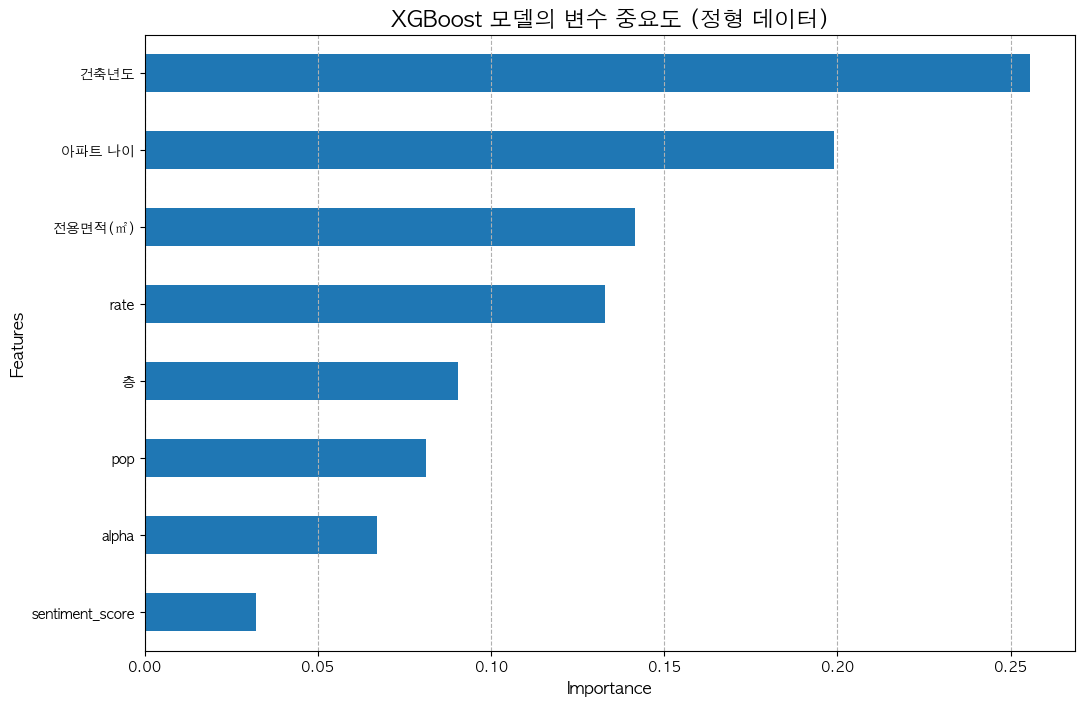

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split

# --- 1. 데이터 준비 (X_tabular 사용) ---
# X_tabular: 숫자형으로 변환된 정형 데이터 DataFrame (8개 특징)
# y_target: 로그 변환된 타겟 변수 (Series)
# (두 변수는 이전 코드에서 이미 생성되어 있어야 합니다)

X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tabular,
    y_target,
    test_size=0.2,
    random_state=42
)

# --- 2. 새로운 XGBoost 모델 학습 ---
print("해석 가능한 특징으로 새로운 XGBoost 모델을 학습합니다...")
xgb_interpretable_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20
)

# 모델 학습
xgb_interpretable_model.fit(
    X_train_tab, y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    verbose=False
)

# --- 3. 변수 중요도 추출 및 시각화 ---
# 이제 모델의 특징 개수와 X_train_tab의 컬럼 개수가 일치합니다.
feature_importances = pd.Series(
    xgb_interpretable_model.feature_importances_, 
    index=X_train_tab.columns
)

# 한글 폰트 설정 (이전에 설정했다면 생략 가능)
try:
    font_name = fm.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
    plt.rc('font', family=font_name)
except FileNotFoundError:
    print("Malgun Gothic 폰트를 찾을 수 없어 기본 폰트로 시각화합니다.")
plt.rc('axes', unicode_minus=False)

# 가장 중요한 특징들을 시각화
plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title('XGBoost 모델의 변수 중요도 (정형 데이터)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, axis='x', linestyle='--')
plt.show()

In [69]:
X_tabular

,전용면적(㎡),층,건축년도,아파트 나이,alpha,sentiment_score,pop,rate
0,-0.168894,-0.474505,0.876093,-1.094846,1.229635,-0.828239,-1.069981,-1.378724
1,-0.741801,-0.721736,-0.250090,0.030231,-0.617168,-0.828239,-1.069981,-1.378724
2,-0.171808,-0.474505,1.036976,-1.255572,1.229635,-0.828239,-1.069981,-1.378724
3,0.100525,0.267189,-1.295831,1.074946,-1.179238,-0.828239,-1.069981,-1.378724
4,0.436290,-0.968967,0.313002,-0.532308,-0.055097,-0.828239,-1.069981,-1.378724
...,...,...,...,...,...,...,...,...
8778,-1.268424,0.143573,0.393443,-0.210857,-0.376280,0.401611,1.166440,0.161414
8779,-0.197360,-0.103658,-1.054506,1.235671,-1.179238,0.401611,1.166440,0.161414
8780,-0.738215,-0.474505,-0.330531,0.512407,-1.098942,0.401611,1.166440,0.161414
8781,1.318290,-0.227274,1.197859,-1.014484,0.426677,0.401611,1.166440,0.161414


In [70]:
# 시계열이 아닌 개별 데이터를 사용하므로, 시퀀스 생성을 하지 않습니다.
# all_features와 y_target을 짝에 맞게 분리합니다.
X_train, X_test, y_train, y_test = train_test_split(
    all_features, 
    y_target, 
    test_size=0.2, 
    random_state=42 # 시계열이 아니므로 랜덤 분리 가능
)

def create_mlp_model(input_shape):
    input_layer = Input(shape=(input_shape,))
    x = Dense(128, activation='relu')(input_layer)
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    # x = Dense(16, activation='relu')(x)
    # x = Dense(8, activation='relu')(x)
    prediction = Dense(1, activation='linear')(x)
    model = Model(inputs=input_layer, outputs=prediction)
    return model

# MLP 모델 생성 및 학습
mlp_model = create_mlp_model(X_train.shape[1])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
mlp_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
mlp_model.summary()

history = mlp_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# 이 모델의 예측 결과를 시각화하여 수평선이 나오는지 확인합니다.

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 256)]             0         
                                                                 
 dense_8 (Dense)             (None, 128)               32896     
                                                                 
 dense_9 (Dense)             (None, 64)                8256      
                                                                 
 dense_10 (Dense)            (None, 32)                2080      
                                                                 
 dense_11 (Dense)            (None, 1)                 33        
                                                                 
Total params: 43,265
Trainable params: 43,265
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
220/220 [==============================] - 0s


--- MLP 기본 모델 모델 성능 분석 시작 ---
55/55 [==============================] - 0s 211us/step
--- MLP 기본 모델: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 4074.51 (만원)  |  예측 단가: 2857.68 (만원)
실제 단가: 2391.80 (만원)  |  예측 단가: 2741.43 (만원)
실제 단가: 2173.06 (만원)  |  예측 단가: 2060.26 (만원)
실제 단가: 3255.63 (만원)  |  예측 단가: 3145.37 (만원)
실제 단가: 4706.44 (만원)  |  예측 단가: 2961.75 (만원)

--- MLP 기본 모델: 최종 실제 오차 (원본 단위) ---
모델 평가 결과 (Log Scaled MAE): 0.2239
역변환 후 실제 오차 (Real World MAE): 524.30 (만원)


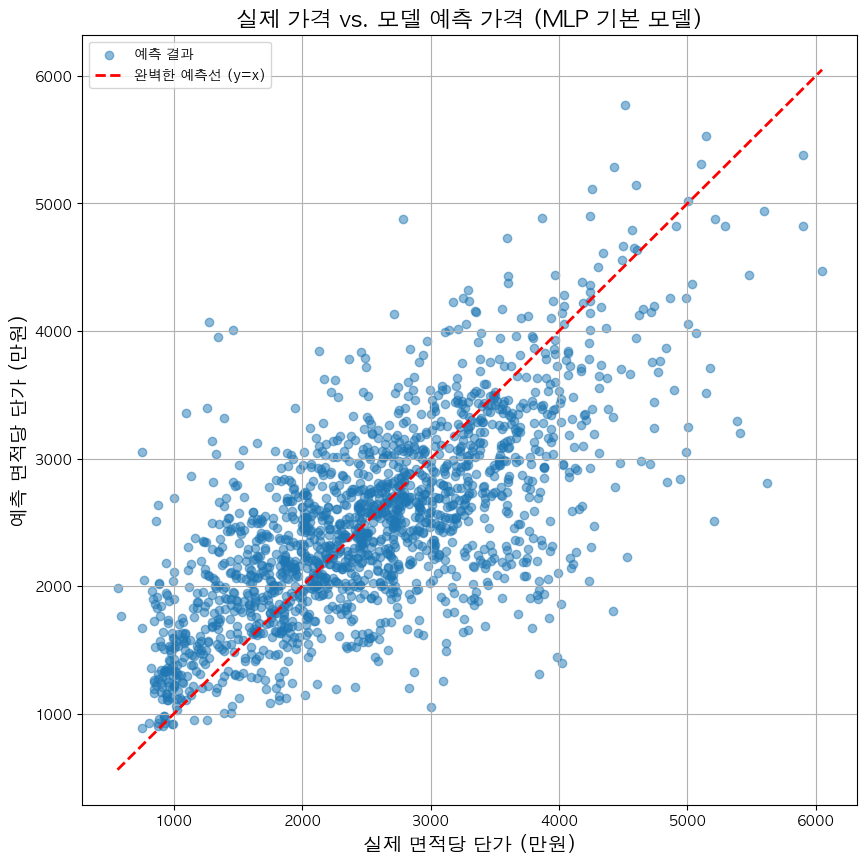

In [71]:
# --- 분석 및 시각화 함수 (수정된 버전) ---
def analyze_and_visualize_model(model, X_test_data, y_test_data, model_name):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 예측 수행
    y_pred_log = model.predict(X_test_data)

    # 2. 역변환
    y_test_original = np.exp(y_test_data)
    y_pred_original = np.exp(y_pred_log)
    
    # ❗️ [수정] Series일 경우를 대비하여 .values를 사용, NumPy 배열로 통일
    y_test_np = y_test_original.values if isinstance(y_test_original, pd.Series) else y_test_original
    # model.predict의 결과는 이미 NumPy 배열이므로 y_pred_original은 그대로 사용
    
    # 3. MAE 계산
    real_world_mae = mean_absolute_error(y_test_np, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(5):
        # ❗️ [수정] .flatten()을 안전하게 사용하기 위해 NumPy 배열인 y_test_np를 사용
        print(f"실제 단가: {y_test_np.flatten()[i]:.2f} (만원)  |  예측 단가: {y_pred_original.flatten()[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    _, scaled_mae = model.evaluate(X_test_data, y_test_data, verbose=0)
    print(f"모델 평가 결과 (Log Scaled MAE): {scaled_mae:.4f}")
    print(f"역변환 후 실제 오차 (Real World MAE): {real_world_mae:.2f} (만원)")

    # 5. 시각화
    plt.figure(figsize=(10, 10))
    # ❗️ [수정] 시각화 시에도 NumPy 배열인 y_test_np를 사용
    plt.scatter(y_test_np, y_pred_original, alpha=0.5, label='예측 결과')
    plt.plot([min(y_test_np.flatten()), max(y_test_np.flatten())], 
             [min(y_test_np.flatten()), max(y_test_np.flatten())], 
             '--r', linewidth=2, label='완벽한 예측선 (y=x)')
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name})", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 함수 재호출 ---
# 이제 MLP 모델에 대한 분석을 다시 실행합니다.
analyze_and_visualize_model(mlp_model, X_test, y_test, "MLP 기본 모델")

# 데이터 분석

In [72]:
X_tabular

,전용면적(㎡),층,건축년도,아파트 나이,alpha,sentiment_score,pop,rate
0,-0.168894,-0.474505,0.876093,-1.094846,1.229635,-0.828239,-1.069981,-1.378724
1,-0.741801,-0.721736,-0.250090,0.030231,-0.617168,-0.828239,-1.069981,-1.378724
2,-0.171808,-0.474505,1.036976,-1.255572,1.229635,-0.828239,-1.069981,-1.378724
3,0.100525,0.267189,-1.295831,1.074946,-1.179238,-0.828239,-1.069981,-1.378724
4,0.436290,-0.968967,0.313002,-0.532308,-0.055097,-0.828239,-1.069981,-1.378724
...,...,...,...,...,...,...,...,...
8778,-1.268424,0.143573,0.393443,-0.210857,-0.376280,0.401611,1.166440,0.161414
8779,-0.197360,-0.103658,-1.054506,1.235671,-1.179238,0.401611,1.166440,0.161414
8780,-0.738215,-0.474505,-0.330531,0.512407,-1.098942,0.401611,1.166440,0.161414
8781,1.318290,-0.227274,1.197859,-1.014484,0.426677,0.401611,1.166440,0.161414


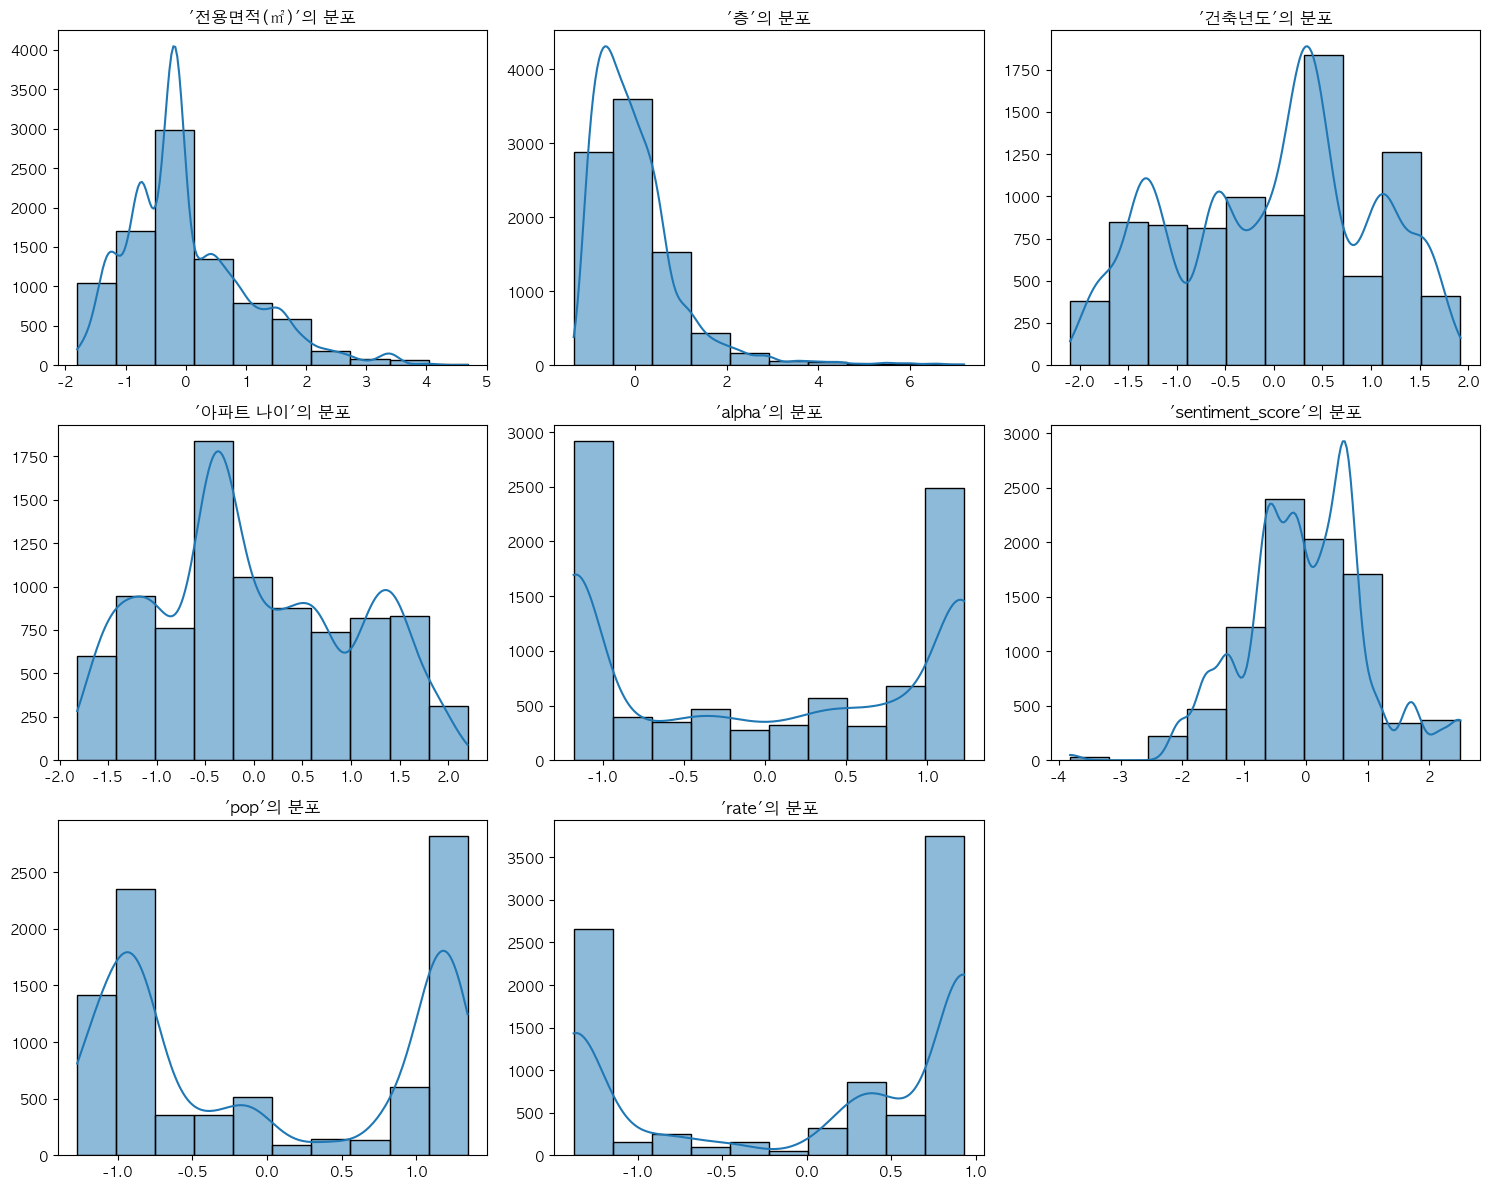

In [73]:

# 2. 각 피처(항목)별로 히스토그램 및 KDE 플롯 시각화
features = X_tabular.columns
num_features = len(features)

# 그래프를 여러 개 그리기 위한 설정
plt.figure(figsize=(15, 12))

for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1) # 3x3 격자에 그래프를 하나씩 추가
    # 히스토그램과 KDE(커널 밀도 추정) 곡선을 함께 그립니다.
    sns.histplot(X_tabular[feature], kde=True, bins=10) # bins는 막대 개수
    plt.title(f"'{feature}'의 분포", fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout() # 그래프 간격 자동 조절
plt.show()
